In [1]:
import torch.nn as nn

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from utility.model import ModelConfig, EarlyStopping

In [2]:
# Parameters

r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

In [3]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

# loss_weights = {
#     'variational': 5,
#     'terminal': 5,
#     'Smax': 3,
#     'Smin': 3
# }

In [4]:
# seeds = [40, 41, 42, 43, 44]
seeds = range(30)
for seed in seeds:
    print("Training with seed:", seed)
    pinn = BlackScholesPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigma, T, S_min, S_max)

    early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
    pinn.train(batch_size=4096, epochs=30000, early_stopping=early_stopping, anneal_freq=500, alpha=0.9)
    pinn.save(f'../models/bs_pinn_1d/annealed/{seed}.pth')

Training with seed: 0
Iter      0 | Train: 2.6685e-01 | Val: 9.9483e-01 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter    500 | Train: 3.0106e-03 | Val: 1.1835e-02 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   1000 | Train: 1.1032e-03 | Val: 4.4745e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   1500 | Train: 7.7539e-04 | Val: 3.0707e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   2000 | Train: 2.6524e-04 | Val: 1.0274e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   2500 | Train: 1.1969e-04 | Val: 5.1126e-04 | Weights: variational=0.210  terminal=0.229  Smin=0.303  Smax=0.258
Iter   3000 | Train: 8.9316e-05 | Val: 3.6847e-04 | Weights: variational=0.240  terminal=0.244  Smin=0.256  Smax=0.261
Iter   3500 | Train: 6.9465e-05 | Val: 2.7726e-04 | Weights: variational=0.445  terminal=0.189  Smin=0.131  Smax=0.236
Iter   4000 | Train: 7.034

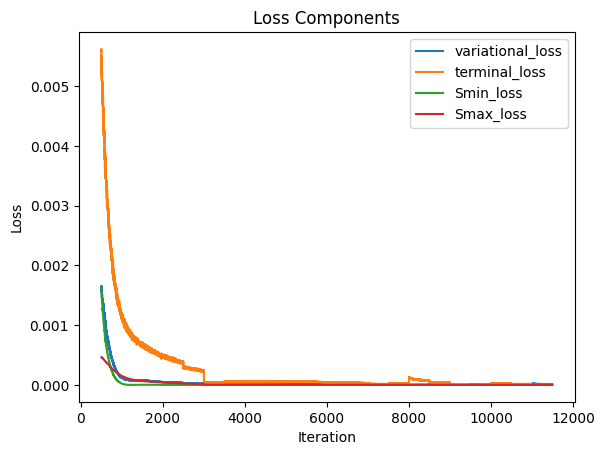

In [5]:
pinn.plot_losses(start_epoch=500, detailed=True)